In [53]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [54]:
df = pd.read_csv("WELFake_Dataset.csv", engine='python', on_bad_lines='skip')

In [55]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [57]:
print(f"Missing values before: {df['text'].isnull().sum()}")

Missing values before: 31


In [77]:
df = df.dropna(subset=['text'])

In [78]:
df = df.dropna(subset=['label'])

In [79]:
print(f"Rows remaining: {len(df)}")

Rows remaining: 26870


In [80]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

In [81]:
X = tfidf.fit_transform(df['text'].astype(str)).toarray()
y = df['label'].values

In [82]:
df['label'] = pd.to_numeric(df['label'], errors='coerce')

In [83]:
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [85]:
model = Sequential([
    Dense(128, input_dim=X_train.shape[1], activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [86]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [87]:
print("\nStarting training...")
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


Starting training...
Epoch 1/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9029 - loss: 0.2435 - val_accuracy: 0.9352 - val_loss: 0.1718
Epoch 2/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9568 - loss: 0.1161 - val_accuracy: 0.9364 - val_loss: 0.1748
Epoch 3/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9787 - loss: 0.0631 - val_accuracy: 0.9349 - val_loss: 0.1929
Epoch 4/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9930 - loss: 0.0251 - val_accuracy: 0.9347 - val_loss: 0.2545
Epoch 5/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9973 - loss: 0.0100 - val_accuracy: 0.9364 - val_loss: 0.2946
Epoch 6/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9989 - loss: 0.0047 - val_accuracy: 0.9364 - val_loss: 0.3354
Epoch 7/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9993 - loss: 0.0030 - val_accuracy: 0.9365 - val_loss: 0.3633
Epoch 8/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9994 -

In [89]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%")

168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9364 - loss: 0.4207

Final Test Accuracy: 93.64%


In [90]:
def predict_news(headline):
    vec = tfidf.transform([headline]).toarray()
    prediction = model.predict(vec)
    return "Fake News" if prediction >= 0.5 else "Real News"

print(f"Prediction: {predict_news('Scientists confirm water on Mars.')}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Prediction: Fake News


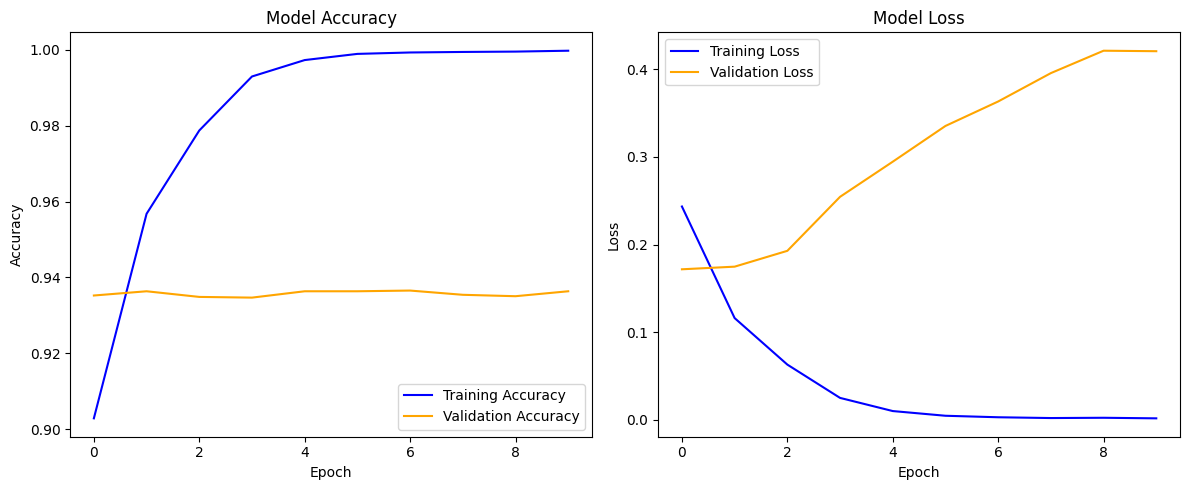

In [91]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()